<a href="https://colab.research.google.com/github/adib2one/.com/blob/main/Deep_Learning_Elastic%20Optical%20Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model 1

In [ ]:
# Import Library
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
import shap
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch.utils.data import TensorDataset, DataLoader
print(f"SHAP version: {shap.__version__}")

SHAP version: 0.52.0


In [ ]:
#/content/dl_training_dataset_multiload_30k.csv
df = pd.read_csv('/content/dl_training_dataset_baseline_KSP-FF_Skripsi.csv', sep=',', on_bad_lines='skip')
df.head()

,timestamp,efm_mean,efm_std,entropy_mean,entropy_std,traffic_load,resource_util,abp_mean
0,20.023063,0.032357,0.056783,0.023413,0.037259,0.000000,0.046733,0.002090
1,25.019752,0.043371,0.095160,0.022915,0.046356,11.495017,0.033878,0.001535
2,30.084103,0.099958,0.175280,0.040294,0.068976,19.681397,0.062074,0.004759
3,35.095932,0.030481,0.060599,0.019155,0.034549,24.562950,0.025923,0.001103
4,40.118204,0.042301,0.079309,0.025236,0.042110,31.241550,0.037216,0.002972


In [ ]:
df = df.drop(labels = ['entropy_mean','efm_mean'],axis = 1)
df.head()

,timestamp,efm_std,entropy_std,traffic_load,resource_util,abp_mean
0,20.023063,0.056783,0.037259,0.000000,0.046733,0.002090
1,25.019752,0.095160,0.046356,11.495017,0.033878,0.001535
2,30.084103,0.175280,0.068976,19.681397,0.062074,0.004759
3,35.095932,0.060599,0.034549,24.562950,0.025923,0.001103
4,40.118204,0.079309,0.042110,31.241550,0.037216,0.002972


In [ ]:
print(df.duplicated().sum())
print(df.isnull().values.any())

0
False


In [ ]:
cols_to_corr = ['traffic_load', 'efm_std', 'entropy_std', 'abp_mean']
correlation_matrix = df[cols_to_corr].corr()
print("Correlation with traffic_load:")
display(correlation_matrix[['traffic_load']])

Correlation with traffic_load:


,traffic_load
traffic_load,1.000000
efm_std,0.589693
entropy_std,0.428775
abp_mean,0.609962


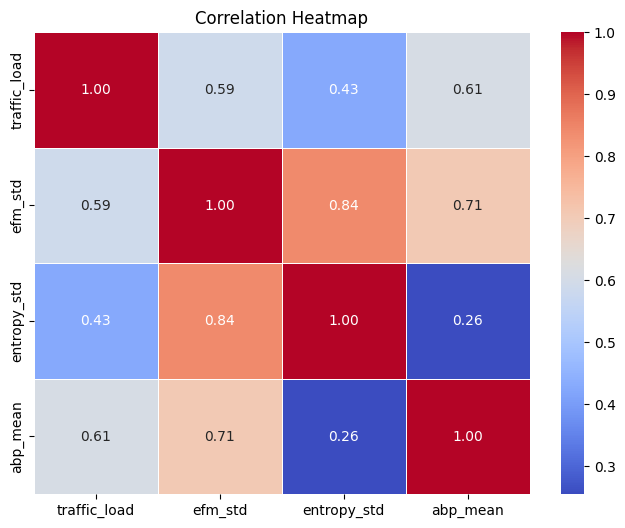

In [ ]:
# Calculate correlation matrix
correlation_matrix = df[['traffic_load', 'efm_std', 'entropy_std', 'abp_mean']].corr()

# Create heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
X = df.iloc[:,0:5]
print(X)

        timestamp   efm_std  entropy_std  traffic_load  resource_util
0       20.023063  0.056783     0.037259      0.000000       0.046733
1       25.019752  0.095160     0.046356     11.495017       0.033878
2       30.084103  0.175280     0.068976     19.681397       0.062074
3       35.095932  0.060599     0.034549     24.562950       0.025923
4       40.118204  0.079309     0.042110     31.241550       0.037216
...           ...       ...          ...           ...            ...
14581  546.605399  0.041483     0.021054    567.761950       0.005398
14582  594.975683  0.041483     0.021068    521.604086       0.005114
14583  595.492664  0.007570     0.006352    521.151251       0.002131
14584  603.504430  0.007570     0.006334    514.232758       0.001491
14585  642.325637  0.002404     0.002861    483.153293       0.000710

[14586 rows x 5 columns]


In [ ]:
y = df.iloc[:,-1]
print(y)

0        0.002090
1        0.001535
2        0.004759
3        0.001103
4        0.002972
           ...   
14581    0.000636
14582    0.000636
14583    0.000253
14584    0.000253
14585    0.000126
Name: abp_mean, Length: 14586, dtype: float64


## Based DNN

Starting 5-Fold Cross Validation...

Fold 1/5
Epoch 10/100 | Train Loss: 0.000039 | Validation Loss: 0.000113 | R²: 0.7826 | MAE: 0.008804 | RMSE: 0.015030
Epoch 20/100 | Train Loss: 0.000030 | Validation Loss: 0.000119 | R²: 0.7721 | MAE: 0.008955 | RMSE: 0.015389
Epoch 30/100 | Train Loss: 0.000028 | Validation Loss: 0.000074 | R²: 0.8571 | MAE: 0.006743 | RMSE: 0.012186
Epoch 40/100 | Train Loss: 0.000026 | Validation Loss: 0.000060 | R²: 0.8859 | MAE: 0.006689 | RMSE: 0.010888
Epoch 50/100 | Train Loss: 0.000028 | Validation Loss: 0.000055 | R²: 0.8953 | MAE: 0.005764 | RMSE: 0.010428
Epoch 60/100 | Train Loss: 0.000025 | Validation Loss: 0.000051 | R²: 0.9013 | MAE: 0.007089 | RMSE: 0.010124
Epoch 70/100 | Train Loss: 0.000026 | Validation Loss: 0.000045 | R²: 0.9145 | MAE: 0.005536 | RMSE: 0.009425
Epoch 80/100 | Train Loss: 0.000026 | Validation Loss: 0.000043 | R²: 0.9179 | MAE: 0.005393 | RMSE: 0.009236
Epoch 90/100 | Train Loss: 0.000026 | Validation Loss: 0.000040 | R²: 0.92

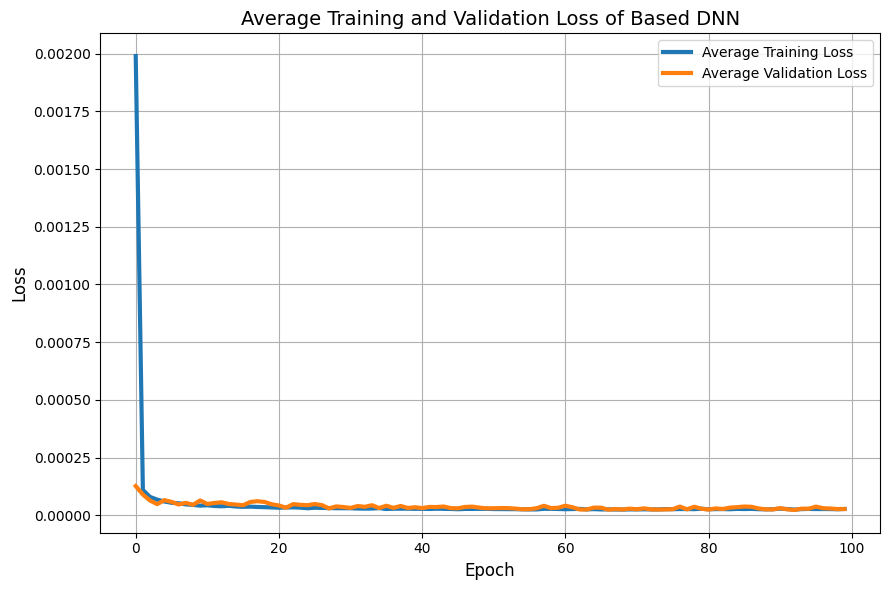

In [ ]:
# ==========================================================
# BetterDNN (ReLU)
# ==========================================================

class BetterDNN(nn.Module):

    def __init__(self):
        super(BetterDNN, self).__init__()

        self.fc1 = nn.Linear(5,128)
        self.bn1 = nn.BatchNorm1d(128)
        self.dropout1 = nn.Dropout(0.5)

        self.fc2 = nn.Linear(128,64)
        self.bn2 = nn.BatchNorm1d(64)
        self.dropout2 = nn.Dropout(0.5)

        self.fc3 = nn.Linear(64,32)
        self.fc4 = nn.Linear(32,1)

    def forward(self,x):

        x = self.fc1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        x = self.dropout2(x)

        x = torch.relu(self.fc3(x))

        x = self.fc4(x)

        return x


# ==========================================================
# Hyperparameter
# ==========================================================

epochs = 100
batch_size = 128
learning_rate = 0.01

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ==========================================================
# Storage
# ==========================================================

history_train = []
history_val = []

fold_train_losses = []
fold_val_losses = []

# Menyimpan seluruh performa setiap fold
performance = []

print("Starting 5-Fold Cross Validation...\n")

# ==========================================================
# Training
# ==========================================================

for fold,(train_idx,val_idx) in enumerate(kf.split(X)):

    print("="*60)
    print(f"Fold {fold+1}/5")
    print("="*60)

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    X_train = torch.tensor(X_train,dtype=torch.float32)
    y_train = torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

    X_val = torch.tensor(X_val,dtype=torch.float32)
    y_val = torch.tensor(y_val.values,dtype=torch.float32).view(-1,1)

    train_loader = DataLoader(
        TensorDataset(X_train,y_train),
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        TensorDataset(X_val,y_val),
        batch_size=batch_size,
        shuffle=False
    )

    model = BetterDNN()

    criterion = nn.HuberLoss(delta=1.0)

    optimizer = optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=1e-2
)

    train_losses = []
    val_losses = []

    # ======================================================
    # Epoch
    # ======================================================

    for epoch in range(epochs):

        ##########################
        # Training
        ##########################

        model.train()

        running_train_loss = 0

        for xb,yb in train_loader:

            optimizer.zero_grad()

            pred = model(xb)

            loss = criterion(pred,yb)

            loss.backward()

            optimizer.step()

            running_train_loss += loss.item()

        train_loss = running_train_loss/len(train_loader)

        ##########################
        # Validation
        ##########################

        model.eval()

        running_val_loss = 0

        preds = []
        labels = []

        with torch.no_grad():

            for xb,yb in val_loader:

                pred = model(xb)

                loss = criterion(pred,yb)

                running_val_loss += loss.item()

                preds.append(pred)

                labels.append(yb)

        val_loss = running_val_loss/len(val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if (epoch+1)%10==0:

            pred_np = torch.cat(preds).cpu().numpy()
            label_np = torch.cat(labels).cpu().numpy()

            r2 = r2_score(label_np,pred_np)
            mae = mean_absolute_error(label_np,pred_np)
            rmse = np.sqrt(mean_squared_error(label_np,pred_np))

            print(
                f"Epoch {epoch+1:02d}/{epochs} | "
                f"Train Loss: {train_loss:.6f} | "
                f"Validation Loss: {val_loss:.6f} | "
                f"R²: {r2:.4f} | "
                f"MAE: {mae:.6f} | "
                f"RMSE: {rmse:.6f}"
            )

    #########################################################
    # Save Result
    #########################################################

    history_train.append(train_losses)
    history_val.append(val_losses)

    fold_train_losses.append(train_losses[-1])
    fold_val_losses.append(val_losses[-1])

    pred_np = torch.cat(preds).cpu().numpy()
    label_np = torch.cat(labels).cpu().numpy()

    r2 = r2_score(label_np,pred_np)
    mae = mean_absolute_error(label_np,pred_np)
    rmse = np.sqrt(mean_squared_error(label_np,pred_np))

    performance.append({
        "Fold": fold+1,
        "Training Loss": train_losses[-1],
        "Validation Loss": val_losses[-1],
        "R2 Score": r2,
        "MAE": mae,
        "RMSE": rmse
    })

# ==========================================================
# Average Result
# ==========================================================

print("\n")
print("="*60)
print("Average 5-Fold Cross Validation")
print("="*60)
performance_df = pd.DataFrame(performance)

print("\nPerformance of Each Fold")
print(performance_df)

print(f"Average Training Loss   : {np.mean(fold_train_losses):.6f}")
print(f"Average Validation Loss : {np.mean(fold_val_losses):.6f}")
print(f"Average R²             : {performance_df['R2 Score'].mean():.4f}")
print(f"Average MAE            : {performance_df['MAE'].mean():.6f}")
print(f"Average RMSE           : {performance_df['RMSE'].mean():.6f}")

print("\n")
print("="*60)
print("Best Performance")
print("="*60)

best_r2 = performance_df.loc[performance_df["R2 Score"].idxmax()]
best_mae = performance_df.loc[performance_df["MAE"].idxmin()]
best_rmse = performance_df.loc[performance_df["RMSE"].idxmin()]

print("\nBest R² Score")
print(best_r2)

print("\nBest MAE")
print(best_mae)

print("\nBest RMSE")
print(best_rmse)

# ==========================================================
# Average Loss Curve
# ==========================================================

mean_train = np.mean(history_train,axis=0)
mean_val = np.mean(history_val,axis=0)

plt.figure(figsize=(9,6))
plt.plot(
    mean_train,
    linewidth=3,
    label="Average Training Loss"
)

plt.plot(
    mean_val,
    linewidth=3,
    label="Average Validation Loss"
)

plt.title("Average Training and Validation Loss of Based DNN",fontsize=14)

plt.xlabel("Epoch",fontsize=12)
plt.ylabel("Loss",fontsize=12)

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## DNN Leaky

Starting 5-Fold Cross Validation...

Fold 1/5
Epoch 10/100 | Train Loss: 0.000040 | Val Loss: 0.000028 | R²: 0.9466 | MAE: 0.005564 | RMSE: 0.007447
Epoch 20/100 | Train Loss: 0.000032 | Val Loss: 0.000020 | R²: 0.9610 | MAE: 0.004575 | RMSE: 0.006367
Epoch 30/100 | Train Loss: 0.000031 | Val Loss: 0.000021 | R²: 0.9587 | MAE: 0.004332 | RMSE: 0.006551
Epoch 40/100 | Train Loss: 0.000026 | Val Loss: 0.000023 | R²: 0.9550 | MAE: 0.003780 | RMSE: 0.006839
Epoch 50/100 | Train Loss: 0.000026 | Val Loss: 0.000016 | R²: 0.9700 | MAE: 0.003205 | RMSE: 0.005583
Epoch 60/100 | Train Loss: 0.000024 | Val Loss: 0.000018 | R²: 0.9656 | MAE: 0.003895 | RMSE: 0.005977
Epoch 70/100 | Train Loss: 0.000025 | Val Loss: 0.000016 | R²: 0.9685 | MAE: 0.003643 | RMSE: 0.005720
Epoch 80/100 | Train Loss: 0.000025 | Val Loss: 0.000018 | R²: 0.9652 | MAE: 0.003999 | RMSE: 0.006014
Epoch 90/100 | Train Loss: 0.000026 | Val Loss: 0.000025 | R²: 0.9523 | MAE: 0.005738 | RMSE: 0.007041
Epoch 100/100 | Train Loss:

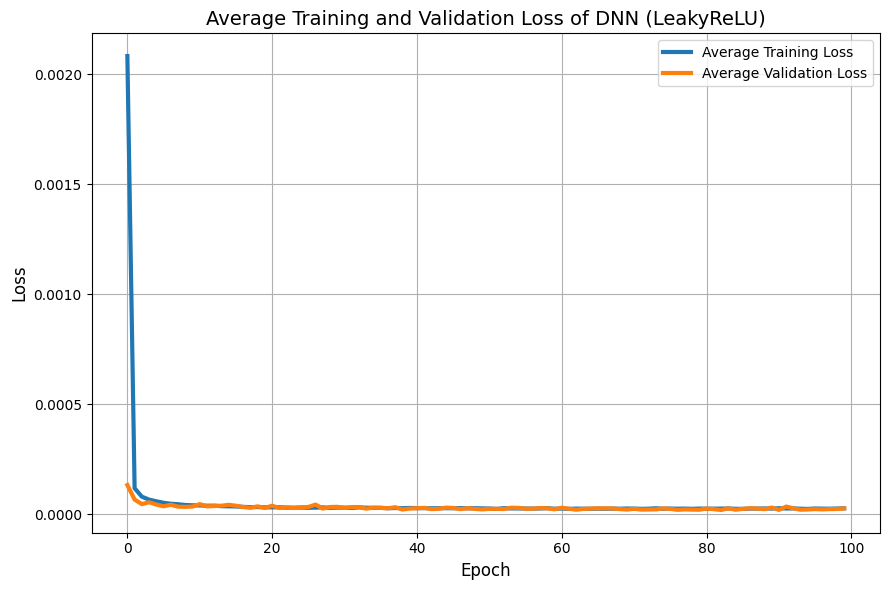

In [ ]:
# ============================================================
# BetterDNN with LeakyReLU
# ============================================================

class BetterDNN_LeakyReLU(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(5, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.dropout1 = nn.Dropout(0.5)

        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.dropout2 = nn.Dropout(0.5)

        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 1)

        self.act = nn.LeakyReLU(negative_slope=0.01)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.act(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.act(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        x = self.act(x)

        x = self.fc4(x)

        return x


# ============================================================
# Hyperparameter
# ============================================================

epochs = 100
batch_size = 128
learning_rate = 0.01

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ============================================================
# Storage
# ============================================================

history_train_leaky = []
history_val_leaky = []

fold_train_losses_leaky = []
fold_val_losses_leaky = []

# Menyimpan seluruh performa setiap fold
performance_leaky = []

print("Starting 5-Fold Cross Validation...\n")

# ============================================================
# K-Fold Training
# ============================================================

# Pastikan X dan y sudah didefinisikan sebelumnya sebagai Pandas DataFrame/Series
# Contoh: X = df[['fitur1', 'fitur2', 'fitur3', 'fitur4', 'fitur5']]
#         y = df['target']

for fold, (train_index, val_index) in enumerate(kf.split(X)):

    print("=" * 60)
    print(f"Fold {fold+1}/5")
    print("=" * 60)

    X_train = X.iloc[train_index]
    X_val = X.iloc[val_index]

    y_train = y.iloc[train_index]
    y_val = y.iloc[val_index]

    # Standardization
    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    # Tensor
    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

    X_val = torch.tensor(X_val, dtype=torch.float32)
    y_val = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

    train_loader = DataLoader(
        TensorDataset(X_train, y_train),
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        TensorDataset(X_val, y_val),
        batch_size=batch_size,
        shuffle=False
    )

    # Model
    model = BetterDNN_LeakyReLU()

    criterion = nn.HuberLoss(delta=1.0)

    optimizer = optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=1e-2
)

    # Memperbaiki nama variabel di sini
    train_losses_leaky = []
    val_losses_leaky = []

    # ========================================================
    # Epoch Training
    # ========================================================

    for epoch in range(epochs):

        # ---------------- TRAIN ----------------
        model.train()
        running_train_loss = 0

        for xb, yb in train_loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item()

        train_loss = running_train_loss / len(train_loader)

        # ---------------- VALIDATION ----------------
        model.eval()
        running_val_loss = 0
        preds = []
        labels = []

        with torch.no_grad():
            for xb, yb in val_loader:
                pred = model(xb)
                loss = criterion(pred, yb)
                running_val_loss += loss.item()
                preds.append(pred)
                labels.append(yb)

        val_loss = running_val_loss / len(val_loader)

        # Memperbaiki variabel append yang sebelumnya salah nama
        train_losses_leaky.append(train_loss)
        val_losses_leaky.append(val_loss)

        if (epoch + 1) % 10 == 0:
            pred_np = torch.cat(preds).cpu().numpy()
            label_np = torch.cat(labels).cpu().numpy()

            r2 = r2_score(label_np, pred_np)
            mae = mean_absolute_error(label_np, pred_np)
            rmse = np.sqrt(mean_squared_error(label_np, pred_np))

            print(
                f"Epoch {epoch+1:02d}/{epochs} | "
                f"Train Loss: {train_loss:.6f} | "
                f"Val Loss: {val_loss:.6f} | "
                f"R²: {r2:.4f} | "
                f"MAE: {mae:.6f} | "
                f"RMSE: {rmse:.6f}"
            )

    # ========================================================
    # Save Fold Result
    # ========================================================

    history_train_leaky.append(train_losses_leaky)
    history_val_leaky.append(val_losses_leaky)

    # Memperbaiki indeks pemanggilan loss
    fold_train_losses_leaky.append(train_losses_leaky[-1])
    fold_val_losses_leaky.append(val_losses_leaky[-1])

    pred_np = torch.cat(preds).cpu().numpy()
    label_np = torch.cat(labels).cpu().numpy()

    r2 = r2_score(label_np, pred_np)
    mae = mean_absolute_error(label_np, pred_np)
    rmse = np.sqrt(mean_squared_error(label_np, pred_np))

    performance_leaky.append({
        "Fold": fold + 1,
        "Training Loss": train_losses_leaky[-1],
        "Validation Loss": val_losses_leaky[-1],
        "R2 Score": r2,
        "MAE": mae,
        "RMSE": rmse
    })

# ============================================================
# Overall Result
# ============================================================

print("\n")
print("=" * 60)
print("Average 5-Fold Cross Validation")
print("=" * 60)
performance_df_leaky = pd.DataFrame(performance_leaky)

print("\nPerformance of Each Fold")
print(performance_df_leaky)

print(f"\nAverage Training Loss   : {np.mean(fold_train_losses_leaky):.6f}")
print(f"Average Validation Loss : {np.mean(fold_val_losses_leaky):.6f}")
print(f"Average R²             : {performance_df_leaky['R2 Score'].mean():.4f}")
print(f"Average MAE            : {performance_df_leaky['MAE'].mean():.6f}")
print(f"Average RMSE           : {performance_df_leaky['RMSE'].mean():.6f}")

print("\n")
print("=" * 60)
print("Best Performance")
print("=" * 60)

best_r2_leaky = performance_df_leaky.loc[performance_df_leaky["R2 Score"].idxmax()]
best_mae_leaky = performance_df_leaky.loc[performance_df_leaky["MAE"].idxmin()]
best_rmse_leaky = performance_df_leaky.loc[performance_df_leaky["RMSE"].idxmin()]

print("\nBest R² Score")
print(best_r2_leaky)

print("\nBest MAE")
print(best_mae_leaky)

print("\nBest RMSE")
print(best_rmse_leaky)

# ============================================================
# Average Loss Curve
# ============================================================

mean_train = np.mean(history_train_leaky, axis=0)
mean_val = np.mean(history_val_leaky, axis=0)

plt.figure(figsize=(9, 6))

plt.plot(
    mean_train,
    linewidth=3,
    label='Average Training Loss'
)

plt.plot(
    mean_val,
    linewidth=3,
    label='Average Validation Loss'
)

plt.title('Average Training and Validation Loss of DNN (LeakyReLU)', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

## Perbandingan R2 Score

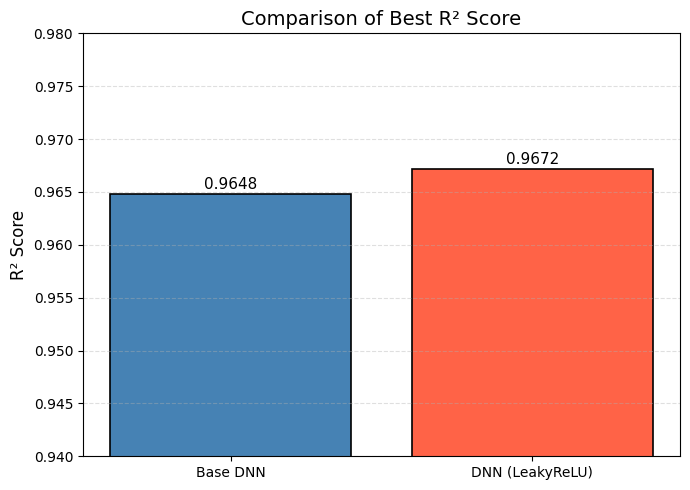

In [ ]:

val_best_r2 = best_r2["R2 Score"]
val_best_r2_leaky = best_r2_leaky["R2 Score"]

models = ["Base DNN", "DNN (LeakyReLU)"]

r2 = [
    val_best_r2,
    val_best_r2_leaky
]

plt.figure(figsize=(7, 5))

bars = plt.bar(
    models,
    r2,
    color=["steelblue", "tomato"],
    edgecolor="black",
    linewidth=1.2
)

plt.ylabel("R² Score", fontsize=12)
# Judul disesuaikan dengan variabel 'best_r2'
plt.title("Comparison of Best R² Score", fontsize=14)

# Pastikan batas bawah (0.94) tidak lebih tinggi dari nilai minimum modelmu,
# sesuaikan jika skor R2 kamu ternyata di bawah 0.94
plt.ylim(0.94, 0.98)

plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0005,
        f"{bar.get_height():.4f}",
        ha='center',
        fontsize=11
    )

plt.tight_layout()
plt.show()

## Perbandingan MAE

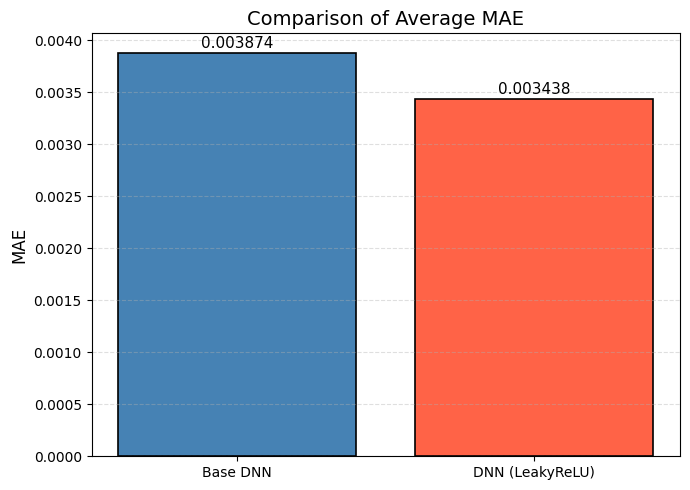

In [ ]:
val_best_mae = best_mae["MAE"]
val_best_mae_leaky = best_mae_leaky["MAE"]

models = ["Base DNN", "DNN (LeakyReLU)"]
mae = [
    val_best_mae,
    val_best_mae_leaky
]

plt.figure(figsize=(7,5))

bars = plt.bar(
    models,
    mae,
    color=["steelblue","tomato"],
    edgecolor="black",
    linewidth=1.2
)

plt.ylabel("MAE", fontsize=12)

plt.title("Comparison of Average MAE", fontsize=14)

plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.00005,
        f"{bar.get_height():.6f}",
        ha='center',
        fontsize=11
    )

plt.tight_layout()
plt.show()

## Perbandingan RMSE

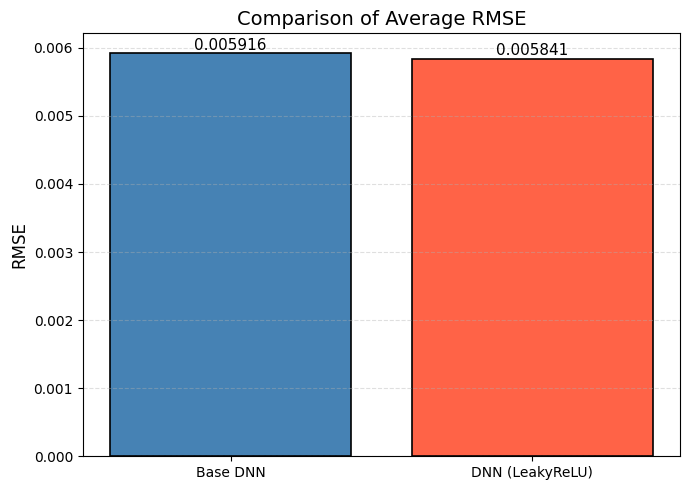

In [ ]:
#val_best_r2 = best_r2["R2 Score"]
#val_best_r2_leaky = best_r2_leaky["R2 Score"]

val_best_rmse = best_rmse["RMSE"]
val_best_rmse_leaky = best_rmse_leaky["RMSE"]
rmse = [
    val_best_rmse,
    val_best_rmse_leaky
]

plt.figure(figsize=(7,5))

bars = plt.bar(
    models,
    rmse,
    color=["steelblue","tomato"],
    edgecolor="black",
    linewidth=1.2
)

plt.ylabel("RMSE", fontsize=12)

plt.title("Comparison of Average RMSE", fontsize=14)

plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.00005,
        f"{bar.get_height():.6f}",
        ha='center',
        fontsize=11
    )

plt.tight_layout()
plt.show()

## Standar Deviasi Kedua Model

In [ ]:
print("\nPerformance of Each Fold")
print(performance_df_leaky)

# Menghitung Rata-rata (Mean)
mean_train = np.mean(fold_train_losses_leaky)
mean_val = np.mean(fold_val_losses_leaky)
mean_r2 = performance_df_leaky['R2 Score'].mean()
mean_mae = performance_df_leaky['MAE'].mean()
mean_rmse = performance_df_leaky['RMSE'].mean()

# Menghitung Standar Deviasi (Std)
# ddof=1 digunakan untuk menghitung sample standard deviation
std_train = np.std(fold_train_losses_leaky, ddof=1)
std_val = np.std(fold_val_losses_leaky, ddof=1)
std_r2 = performance_df_leaky['R2 Score'].std()
std_mae = performance_df_leaky['MAE'].std()
std_rmse = performance_df_leaky['RMSE'].std()

print("\nRingkasan Performa (Mean ± Std):")
print("-" * 40)
print(f"Training Loss   : {mean_train:.6f} ± {std_train:.6f}")
print(f"Validation Loss : {mean_val:.6f} ± {std_val:.6f}")
print(f"R² Score        : {mean_r2:.4f} ± {std_r2:.4f}")
print(f"MAE             : {mean_mae:.6f} ± {std_mae:.6f}")
print(f"RMSE            : {mean_rmse:.6f} ± {std_rmse:.6f}")


Performance of Each Fold
   Fold  Training Loss  Validation Loss  R2 Score       MAE      RMSE
0     1       0.000024         0.000017  0.967161  0.003438  0.005841
1     2       0.000028         0.000019  0.962373  0.004861  0.006116
2     3       0.000030         0.000023  0.950943  0.004471  0.006779
3     4       0.000027         0.000038  0.923414  0.005871  0.008760
4     5       0.000027         0.000037  0.926258  0.007444  0.008655

Ringkasan Performa (Mean ± Std):
----------------------------------------
Training Loss   : 0.000027 ± 0.000002
Validation Loss : 0.000027 ± 0.000010
R² Score        : 0.9460 ± 0.0202
MAE             : 0.005217 ± 0.001520
RMSE            : 0.007230 ± 0.001392


In [ ]:
performance_df = pd.DataFrame(performance)

print("\nPerformance of Each Fold")
print(performance_df)

# Menghitung Rata-rata (Mean)
mean_train = np.mean(fold_train_losses_leaky)
mean_val = np.mean(fold_val_losses_leaky)
mean_r2 = performance_df['R2 Score'].mean()
mean_mae = performance_df['MAE'].mean()
mean_rmse = performance_df['RMSE'].mean()

# Menghitung Standar Deviasi (Std)
# ddof=1 digunakan untuk menghitung sample standard deviation
std_train = np.std(fold_train_losses_leaky, ddof=1)
std_val = np.std(fold_val_losses_leaky, ddof=1)
std_r2 = performance_df['R2 Score'].std()
std_mae = performance_df['MAE'].std()
std_rmse = performance_df['RMSE'].std()

print("\nRingkasan Performa (Mean ± Std):")
print("-" * 40)
print(f"Training Loss   : {mean_train:.6f} ± {std_train:.6f}")
print(f"Validation Loss : {mean_val:.6f} ± {std_val:.6f}")
print(f"R² Score        : {mean_r2:.4f} ± {std_r2:.4f}")
print(f"MAE             : {mean_mae:.6f} ± {std_mae:.6f}")
print(f"RMSE            : {mean_rmse:.6f} ± {std_rmse:.6f}")


Performance of Each Fold
   Fold  Training Loss  Validation Loss  R2 Score       MAE      RMSE
0     1       0.000029         0.000045  0.913760  0.005565  0.009466
1     2       0.000026         0.000017  0.964787  0.004258  0.005916
2     3       0.000027         0.000028  0.940730  0.004163  0.007452
3     4       0.000023         0.000022  0.955566  0.003874  0.006673
4     5       0.000029         0.000022  0.957541  0.004407  0.006567

Ringkasan Performa (Mean ± Std):
----------------------------------------
Training Loss   : 0.000027 ± 0.000002
Validation Loss : 0.000027 ± 0.000010
R² Score        : 0.9465 ± 0.0203
MAE             : 0.004453 ± 0.000651
RMSE            : 0.007215 ± 0.001371


## Analisis SHAP

Calculating SHAP values (this may take a moment)...


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Membuat plot SHAP untuk BetterDNN (ReLU)...


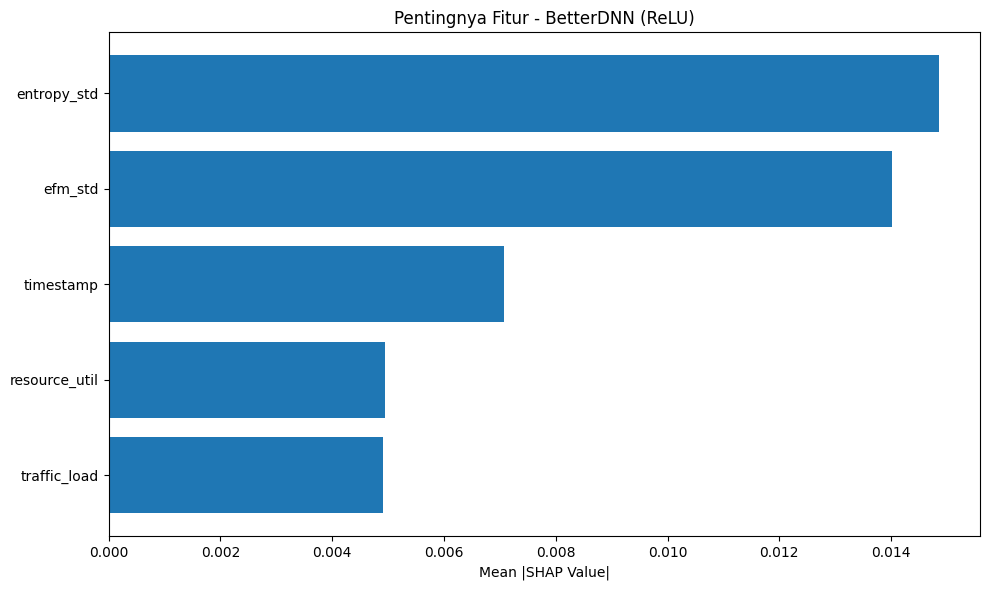

Membuat plot SHAP untuk BetterDNN (LeakyReLU)...


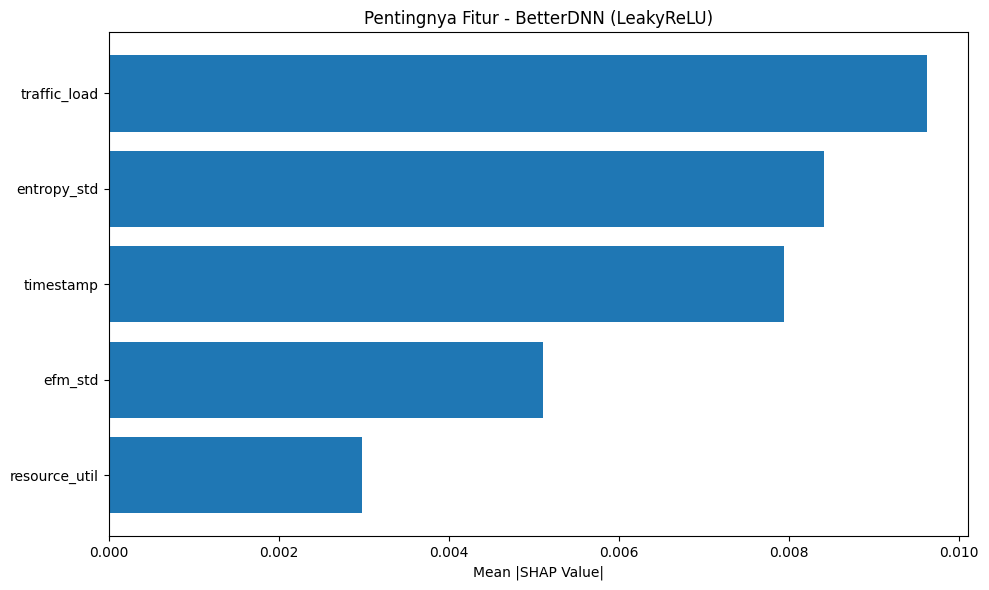

Membuat plot perbandingan SHAP...


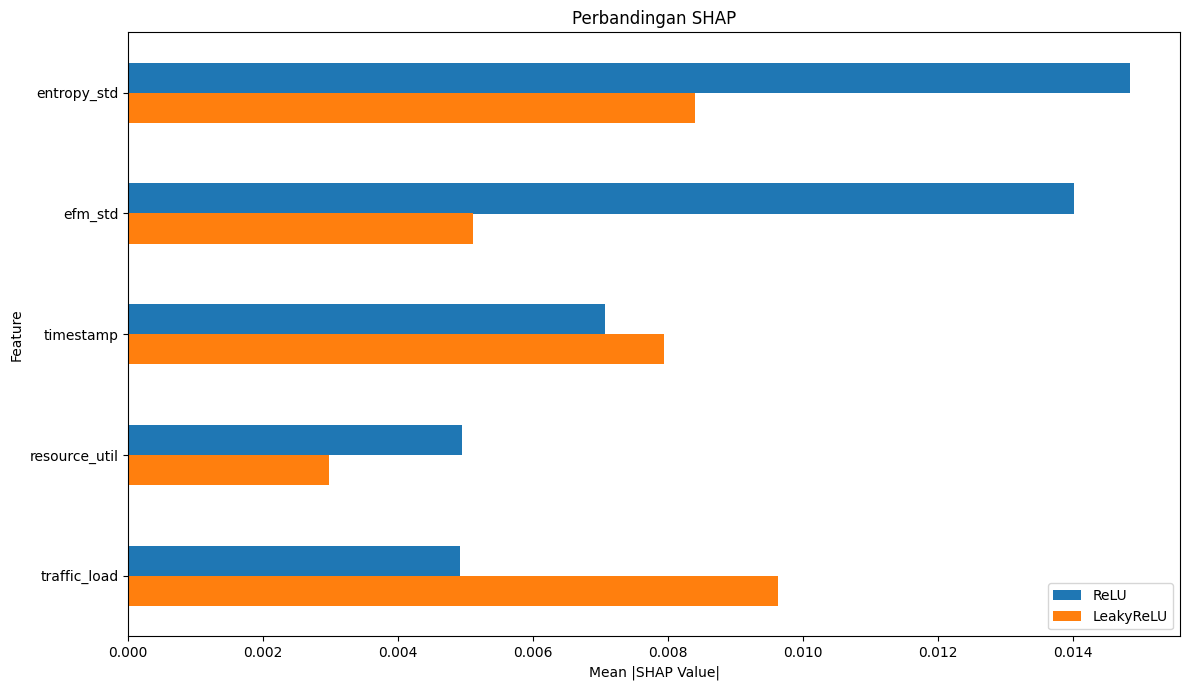

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import shap
from sklearn.preprocessing import StandardScaler

# 1. Re-define Model Architectures (to ensure classes are available)
class BetterDNN(nn.Module):
    def __init__(self):
        super(BetterDNN, self).__init__()
        self.fc1 = nn.Linear(5, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.dropout1 = nn.Dropout(0.2)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.dropout2 = nn.Dropout(0.2)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 1)
    def forward(self, x):
        x = self.dropout1(torch.relu(self.bn1(self.fc1(x))))
        x = self.dropout2(torch.relu(self.bn2(self.fc2(x))))
        x = torch.relu(self.fc3(x))
        return self.fc4(x)

class BetterDNN_LeakyReLU(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(5, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.dropout1 = nn.Dropout(0.2)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.dropout2 = nn.Dropout(0.2)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 1)
        self.act = nn.LeakyReLU(0.01)
    def forward(self, x):
        x = self.dropout1(self.act(self.bn1(self.fc1(x))))
        x = self.dropout2(self.act(self.bn2(self.fc2(x))))
        x = self.act(self.fc3(x))
        return self.fc4(x)

# 2. Instantiate and load/train models briefly for SHAP calculation
# Note: Ideally, you should load weights here if available, e.g., model.load_state_dict(...)
model_base = BetterDNN()
model_leaky = BetterDNN_LeakyReLU()
model_base.eval()
model_leaky.eval()

# 3. Preparation for SHAP
# Using existing X from kernel
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
background = X_scaled[np.random.choice(X_scaled.shape[0], 100, replace=False)]
test_samples = X_scaled[:50]

def predict_base(x):
    with torch.no_grad():
        return model_base(torch.tensor(x, dtype=torch.float32)).numpy()

def predict_leaky(x):
    with torch.no_grad():
        return model_leaky(torch.tensor(x, dtype=torch.float32)).numpy()

print("Calculating SHAP values (this may take a moment)...")
explainer_base = shap.KernelExplainer(predict_base, background)
shap_values_base = explainer_base.shap_values(test_samples)

explainer_leaky = shap.KernelExplainer(predict_leaky, background)
shap_values_leaky = explainer_leaky.shap_values(test_samples)

# 4. Plotting Functions
def plot_mean_shap(shap_values, feature_names, title):
    if isinstance(shap_values, list):
        shap_values = shap_values[0]
    mean_shap = np.mean(np.abs(shap_values), axis=0).flatten()
    shap_df = pd.DataFrame({"Feature": feature_names, "Mean_SHAP": mean_shap}).sort_values(by="Mean_SHAP", ascending=False)

    plt.figure(figsize=(10, 6))
    plt.barh(shap_df["Feature"], shap_df["Mean_SHAP"])
    plt.xlabel("Mean |SHAP Value|")
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    return shap_df

# 5. Visualizations
print("Membuat plot SHAP untuk BetterDNN (ReLU)...")
shap_df_base = plot_mean_shap(shap_values_base, X.columns, "Pentingnya Fitur - BetterDNN (ReLU)")

print("Membuat plot SHAP untuk BetterDNN (LeakyReLU)...")
shap_df_leaky = plot_mean_shap(shap_values_leaky, X.columns, "Pentingnya Fitur - BetterDNN (LeakyReLU)")

# Comparison Plot
sv_base_processed = shap_values_base[0] if isinstance(shap_values_base, list) else shap_values_base
sv_leaky_processed = shap_values_leaky[0] if isinstance(shap_values_leaky, list) else shap_values_leaky

comparison_df = pd.DataFrame({
    "Feature": X.columns,
    "ReLU": np.mean(np.abs(sv_base_processed), axis=0).flatten(),
    "LeakyReLU": np.mean(np.abs(sv_leaky_processed), axis=0).flatten()
}).sort_values(by="ReLU", ascending=False)

print("Membuat plot perbandingan SHAP...")
plt.figure(figsize=(12, 7))
comparison_df.set_index("Feature").plot(kind="barh", ax=plt.gca())
plt.xlabel("Mean |SHAP Value|")
plt.title("Perbandingan SHAP")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
torch.save(model_base.state_dict(), 'better_dnn_relu_model_2.pth')
print("BetterDNN (ReLU) model saved as better_dnn_relu_model.pth")

torch.save(model_leaky.state_dict(), 'better_dnn_leaky_relu_model_2.pth')
print("BetterDNN (LeakyReLU) model saved as better_dnn_leaky_relu_model.pth")

BetterDNN (ReLU) model saved as better_dnn_relu_model.pth
BetterDNN (LeakyReLU) model saved as better_dnn_leaky_relu_model.pth


# Model 2

## Based DNN Model 2

In [ ]:
# ==========================================================
# BetterDNN (ReLU)
# ==========================================================

class BetterDNN(nn.Module):

    def __init__(self):
        super(BetterDNN, self).__init__()

        self.fc1 = nn.Linear(5,128)
        self.bn1 = nn.BatchNorm1d(128)
        self.dropout1 = nn.Dropout(0.5)

        self.fc2 = nn.Linear(128,64)
        self.bn2 = nn.BatchNorm1d(64)
        self.dropout2 = nn.Dropout(0.5)

        self.fc3 = nn.Linear(64,32)
        self.fc4 = nn.Linear(32,1)

    def forward(self,x):

        x = self.fc1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        x = self.dropout2(x)

        x = torch.relu(self.fc3(x))

        x = self.fc4(x)

        return x


# ==========================================================
# Hyperparameter
# ==========================================================

epochs = 100
batch_size = 128
learning_rate = 0.01

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ==========================================================
# Storage
# ==========================================================

history_train = []
history_val = []

fold_train_losses = []
fold_val_losses = []

# Menyimpan seluruh performa setiap fold
performance = []

print("Starting 5-Fold Cross Validation...\n")

# ==========================================================
# Training
# ==========================================================

for fold,(train_idx,val_idx) in enumerate(kf.split(X)):

    print("="*60)
    print(f"Fold {fold+1}/5")
    print("="*60)

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    X_train = torch.tensor(X_train,dtype=torch.float32)
    y_train = torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

    X_val = torch.tensor(X_val,dtype=torch.float32)
    y_val = torch.tensor(y_val.values,dtype=torch.float32).view(-1,1)

    train_loader = DataLoader(
        TensorDataset(X_train,y_train),
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        TensorDataset(X_val,y_val),
        batch_size=batch_size,
        shuffle=False
    )

    model = BetterDNN()

    criterion = nn.HuberLoss(delta=1.0)

    optimizer = optim.AdamW(
    model_fold.parameters(),
    lr=learning_rate,
    weight_decay=1e-2
)

    train_losses = []
    val_losses = []

    # ======================================================
    # Epoch
    # ======================================================

    for epoch in range(epochs):

        ##########################
        # Training
        ##########################

        model.train()

        running_train_loss = 0

        for xb,yb in train_loader:

            optimizer.zero_grad()

            pred = model(xb)

            loss = criterion(pred,yb)

            loss.backward()

            optimizer.step()

            running_train_loss += loss.item()

        train_loss = running_train_loss/len(train_loader)

        ##########################
        # Validation
        ##########################

        model.eval()

        running_val_loss = 0

        preds = []
        labels = []

        with torch.no_grad():

            for xb,yb in val_loader:

                pred = model(xb)

                loss = criterion(pred,yb)

                running_val_loss += loss.item()

                preds.append(pred)

                labels.append(yb)

        val_loss = running_val_loss/len(val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if (epoch+1)%10==0:

            pred_np = torch.cat(preds).cpu().numpy()
            label_np = torch.cat(labels).cpu().numpy()

            r2 = r2_score(label_np,pred_np)
            mae = mean_absolute_error(label_np,pred_np)
            rmse = np.sqrt(mean_squared_error(label_np,pred_np))

            print(
                f"Epoch {epoch+1:02d}/{epochs} | "
                f"Train Loss: {train_loss:.6f} | "
                f"Validation Loss: {val_loss:.6f} | "
                f"R²: {r2:.4f} | "
                f"MAE: {mae:.6f} | "
                f"RMSE: {rmse:.6f}"
            )

    #########################################################
    # Save Result
    #########################################################

    history_train.append(train_losses)
    history_val.append(val_losses)

    fold_train_losses.append(train_losses[-1])
    fold_val_losses.append(val_losses[-1])

    pred_np = torch.cat(preds).cpu().numpy()
    label_np = torch.cat(labels).cpu().numpy()

    r2 = r2_score(label_np,pred_np)
    mae = mean_absolute_error(label_np,pred_np)
    rmse = np.sqrt(mean_squared_error(label_np,pred_np))

    performance.append({
        "Fold": fold+1,
        "Training Loss": train_losses[-1],
        "Validation Loss": val_losses[-1],
        "R2 Score": r2,
        "MAE": mae,
        "RMSE": rmse
    })

# ==========================================================
# Average Result
# ==========================================================

print("\n")
print("="*60)
print("Average 5-Fold Cross Validation")
print("="*60)
performance_df = pd.DataFrame(performance)

print("\nPerformance of Each Fold")
print(performance_df)

print(f"Average Training Loss   : {np.mean(fold_train_losses):.6f}")
print(f"Average Validation Loss : {np.mean(fold_val_losses):.6f}")
print(f"Average R²             : {performance_df['R2 Score'].mean():.4f}")
print(f"Average MAE            : {performance_df['MAE'].mean():.6f}")
print(f"Average RMSE           : {performance_df['RMSE'].mean():.6f}")

print("\n")
print("="*60)
print("Best Performance")
print("="*60)

best_r2 = performance_df.loc[performance_df["R2 Score"].idxmax()]
best_mae = performance_df.loc[performance_df["MAE"].idxmin()]
best_rmse = performance_df.loc[performance_df["RMSE"].idxmin()]

print("\nBest R² Score")
print(best_r2)

print("\nBest MAE")
print(best_mae)

print("\nBest RMSE")
print(best_rmse)

# ==========================================================
# Average Loss Curve
# ==========================================================

mean_train = np.mean(history_train,axis=0)
mean_val = np.mean(history_val,axis=0)

plt.figure(figsize=(9,6))
plt.plot(
    mean_train,
    linewidth=3,
    label="Average Training Loss"
)

plt.plot(
    mean_val,
    linewidth=3,
    label="Average Validation Loss"
)

plt.title("Average Training and Validation Loss of Based DNN",fontsize=14)

plt.xlabel("Epoch",fontsize=12)
plt.ylabel("Loss",fontsize=12)

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## DNN Leaky Model 2

In [ ]:
# ============================================================
# BetterDNN with LeakyReLU
# ============================================================

class BetterDNN_LeakyReLU(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(5, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.dropout1 = nn.Dropout(0.5)

        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.dropout2 = nn.Dropout(0.5)

        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 1)

        self.act = nn.LeakyReLU(negative_slope=0.01)

    def forward(self, x):

        x = self.fc1(x)
        x = self.bn1(x)
        x = self.act(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.act(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        x = self.act(x)

        x = self.fc4(x)

        return x


# ============================================================
# Hyperparameter
# ============================================================

epochs = 100
batch_size = 128
learning_rate = 0.01

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ============================================================
# Storage
# ============================================================

history_train = []
history_val = []

fold_train_losses = []
fold_val_losses = []

# Menyimpan seluruh performa setiap fold
performance = []

print("Starting 5-Fold Cross Validation...\n")

# ============================================================
# K-Fold Training
# ============================================================

for fold, (train_index, val_index) in enumerate(kf.split(X)):

    print("=" * 60)
    print(f"Fold {fold+1}/5")
    print("=" * 60)

    X_train = X.iloc[train_index]
    X_val = X.iloc[val_index]

    y_train = y.iloc[train_index]
    y_val = y.iloc[val_index]

    # Standardization
    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    # Tensor
    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

    X_val = torch.tensor(X_val, dtype=torch.float32)
    y_val = torch.tensor(y_val.values, dtype=torch.float32).view(-1,1)

    train_loader = DataLoader(
        TensorDataset(X_train,y_train),
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        TensorDataset(X_val,y_val),
        batch_size=batch_size,
        shuffle=False
    )

    # Model
    model = BetterDNN_LeakyReLU()

    criterion = nn.HuberLoss(delta=1.0)

    optimizer = optim.AdamW(
    model_fold.parameters(),
    lr=learning_rate,
    weight_decay=1e-2
)
    train_losses = []
    val_losses = []

    # ========================================================
    # Epoch Training
    # ========================================================

    for epoch in range(epochs):

        # ---------------- TRAIN ----------------

        model.train()

        running_train_loss = 0

        for xb, yb in train_loader:

            optimizer.zero_grad()

            pred = model(xb)

            loss = criterion(pred, yb)

            loss.backward()

            optimizer.step()

            running_train_loss += loss.item()

        train_loss = running_train_loss / len(train_loader)

        # ---------------- VALIDATION ----------------

        model.eval()

        running_val_loss = 0

        preds = []
        labels = []

        with torch.no_grad():

            for xb, yb in val_loader:

                pred = model(xb)

                loss = criterion(pred, yb)

                running_val_loss += loss.item()

                preds.append(pred)

                labels.append(yb)

        val_loss = running_val_loss / len(val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if (epoch + 1) % 10 == 0:

            pred_np = torch.cat(preds).cpu().numpy()
            label_np = torch.cat(labels).cpu().numpy()

            r2 = r2_score(label_np, pred_np)
            mae = mean_absolute_error(label_np, pred_np)
            rmse = np.sqrt(mean_squared_error(label_np, pred_np))

            print(
                f"Epoch {epoch+1:02d}/{epochs} | "
                f"Train Loss: {train_loss:.6f} | "
                f"Val Loss: {val_loss:.6f} | "
                f"R²: {r2:.4f} | "
                f"MAE: {mae:.6f} | "
                f"RMSE: {rmse:.6f}"
            )

    # ========================================================
    # Save Fold Result
    # ========================================================

    history_train.append(train_losses)
    history_val.append(val_losses)

    fold_train_losses.append(train_losses[-1])
    fold_val_losses.append(val_losses[-1])

    pred_np = torch.cat(preds).cpu().numpy()
    label_np = torch.cat(labels).cpu().numpy()

    r2 = r2_score(label_np,pred_np)
    mae = mean_absolute_error(label_np,pred_np)
    rmse = np.sqrt(mean_squared_error(label_np,pred_np))

    performance.append({
        "Fold": fold+1,
        "Training Loss": train_losses[-1],
        "Validation Loss": val_losses[-1],
        "R2 Score": r2,
        "MAE": mae,
        "RMSE": rmse
    })

# ============================================================
# Overall Result
# ============================================================

print("\n")
print("="*60)
print("Average 5-Fold Cross Validation")
print("="*60)
performance_df = pd.DataFrame(performance)

print("\nPerformance of Each Fold")
print(performance_df)

print(f"Average Training Loss   : {np.mean(fold_train_losses):.6f}")
print(f"Average Validation Loss : {np.mean(fold_val_losses):.6f}")
print(f"Average R²             : {performance_df['R2 Score'].mean():.4f}")
print(f"Average MAE            : {performance_df['MAE'].mean():.6f}")
print(f"Average RMSE           : {performance_df['RMSE'].mean():.6f}")

print("\n")
print("="*60)
print("Best Performance")
print("="*60)

best_r2_leaky = performance_df.loc[performance_df["R2 Score"].idxmax()]
best_mae_leaky = performance_df.loc[performance_df["MAE"].idxmin()]
best_rmse_leaky = performance_df.loc[performance_df["RMSE"].idxmin()]

print("\nBest R² Score")
print(best_r2_leaky)

print("\nBest MAE")
print(best_mae_leaky)

print("\nBest RMSE")
print(best_rmse_leaky)


# ============================================================
# Average Loss Curve
# ============================================================

mean_train = np.mean(history_train, axis=0)
mean_val = np.mean(history_val, axis=0)

plt.figure(figsize=(9,6))

plt.plot(
    mean_train,
    linewidth=3,
    label='Average Training Loss'
)

plt.plot(
    mean_val,
    linewidth=3,
    label='Average Validation Loss'
)

plt.title('Average Training and Validation Loss of DNN (LeakyReLU)', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

In [ ]:
performance_relu = pd.DataFrame(performance)
performance_leaky = pd.DataFrame(performance)

## Perbandingan  R2 Score

In [ ]:
import matplotlib.pyplot as plt

models = ["Based DNN", "DNN (LeakyReLU)"]

r2 = [
    performance_relu["R2 Score"].mean(),
    performance_leaky["R2 Score"].mean()
]

plt.figure(figsize=(7,5))

bars = plt.bar(
    models,
    r2,
    color=["steelblue","tomato"],
    edgecolor="black",
    linewidth=1.2
)

plt.ylabel("R² Score", fontsize=12)
plt.title("Comparison of Average R² Score", fontsize=14)

plt.ylim(0.94,0.98)

plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.0005,
        f"{bar.get_height():.4f}",
        ha='center',
        fontsize=11
    )

plt.tight_layout()
plt.show()

## Perbandingan MAE

In [ ]:
mae = [
    performance_relu["MAE"].mean(),
    performance_leaky["MAE"].mean()
]

plt.figure(figsize=(7,5))

bars = plt.bar(
    models,
    mae,
    color=["steelblue","tomato"],
    edgecolor="black",
    linewidth=1.2
)

plt.ylabel("MAE", fontsize=12)

plt.title("Comparison of Average MAE", fontsize=14)

plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.00005,
        f"{bar.get_height():.6f}",
        ha='center',
        fontsize=11
    )

plt.tight_layout()
plt.show()

## Perbandingan RMSE

In [ ]:
rmse = [
    performance_relu["RMSE"].mean(),
    performance_leaky["RMSE"].mean()
]

plt.figure(figsize=(7,5))

bars = plt.bar(
    models,
    rmse,
    color=["steelblue","tomato"],
    edgecolor="black",
    linewidth=1.2
)

plt.ylabel("RMSE", fontsize=12)

plt.title("Comparison of Average RMSE", fontsize=14)

plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.00005,
        f"{bar.get_height():.6f}",
        ha='center',
        fontsize=11
    )

plt.tight_layout()
plt.show()

## Standar Deviasi Kedua Model

In [ ]:
import numpy as np

# ======================================================
# Statistics of BetterDNN (ReLU)
# ======================================================

relu_r2_mean = performance_relu["R2 Score"].mean()
relu_r2_std  = performance_relu["R2 Score"].std()

relu_mae_mean = performance_relu["MAE"].mean()
relu_mae_std  = performance_relu["MAE"].std()

relu_rmse_mean = performance_relu["RMSE"].mean()
relu_rmse_std  = performance_relu["RMSE"].std()


# ======================================================
# Statistics of BetterDNN (LeakyReLU)
# ======================================================

leaky_r2_mean = performance_leaky["R2 Score"].mean()
leaky_r2_std  = performance_leaky["R2 Score"].std()

leaky_mae_mean = performance_leaky["MAE"].mean()
leaky_mae_std  = performance_leaky["MAE"].std()

leaky_rmse_mean = performance_leaky["RMSE"].mean()
leaky_rmse_std  = performance_leaky["RMSE"].std()

## Analisis SHAP

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import shap
from sklearn.preprocessing import StandardScaler

# 1. Re-define Model Architectures (to ensure classes are available)
class BetterDNN(nn.Module):
    def __init__(self):
        super(BetterDNN, self).__init__()
        self.fc1 = nn.Linear(5, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.dropout1 = nn.Dropout(0.2)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.dropout2 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 1)
    def forward(self, x):
        x = self.dropout1(torch.relu(self.bn1(self.fc1(x))))
        x = self.dropout2(torch.relu(self.bn2(self.fc2(x))))
        x = torch.relu(self.fc3(x))
        return self.fc4(x)

class BetterDNN_LeakyReLU(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(5, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.dropout1 = nn.Dropout(0.2)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.dropout2 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 1)
        self.act = nn.LeakyReLU(0.01)
    def forward(self, x):
        x = self.dropout1(self.act(self.bn1(self.fc1(x))))
        x = self.dropout2(self.act(self.bn2(self.fc2(x))))
        x = self.act(self.fc3(x))
        return self.fc4(x)

# 2. Instantiate and load/train models briefly for SHAP calculation
# Note: Ideally, you should load weights here if available, e.g., model.load_state_dict(...)
model_base = BetterDNN()
model_leaky = BetterDNN_LeakyReLU()
model_base.eval()
model_leaky.eval()

# 3. Preparation for SHAP
# Using existing X from kernel
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
background = X_scaled[np.random.choice(X_scaled.shape[0], 100, replace=False)]
test_samples = X_scaled[:50]

def predict_base(x):
    with torch.no_grad():
        return model_base(torch.tensor(x, dtype=torch.float32)).numpy()

def predict_leaky(x):
    with torch.no_grad():
        return model_leaky(torch.tensor(x, dtype=torch.float32)).numpy()

print("Calculating SHAP values (this may take a moment)...")
explainer_base = shap.KernelExplainer(predict_base, background)
shap_values_base = explainer_base.shap_values(test_samples)

explainer_leaky = shap.KernelExplainer(predict_leaky, background)
shap_values_leaky = explainer_leaky.shap_values(test_samples)

# 4. Plotting Functions
def plot_mean_shap(shap_values, feature_names, title):
    if isinstance(shap_values, list):
        shap_values = shap_values[0]
    mean_shap = np.mean(np.abs(shap_values), axis=0).flatten()
    shap_df = pd.DataFrame({"Feature": feature_names, "Mean_SHAP": mean_shap}).sort_values(by="Mean_SHAP", ascending=False)

    plt.figure(figsize=(10, 6))
    plt.barh(shap_df["Feature"], shap_df["Mean_SHAP"])
    plt.xlabel("Mean |SHAP Value|")
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    return shap_df

# 5. Visualizations
print("Membuat plot SHAP untuk BetterDNN (ReLU)...")
shap_df_base = plot_mean_shap(shap_values_base, X.columns, "Pentingnya Fitur - BetterDNN (ReLU)")

print("Membuat plot SHAP untuk BetterDNN (LeakyReLU)...")
shap_df_leaky = plot_mean_shap(shap_values_leaky, X.columns, "Pentingnya Fitur - BetterDNN (LeakyReLU)")

# Comparison Plot
sv_base_processed = shap_values_base[0] if isinstance(shap_values_base, list) else shap_values_base
sv_leaky_processed = shap_values_leaky[0] if isinstance(shap_values_leaky, list) else shap_values_leaky

comparison_df = pd.DataFrame({
    "Feature": X.columns,
    "ReLU": np.mean(np.abs(sv_base_processed), axis=0).flatten(),
    "LeakyReLU": np.mean(np.abs(sv_leaky_processed), axis=0).flatten()
}).sort_values(by="ReLU", ascending=False)

print("Membuat plot perbandingan SHAP...")
plt.figure(figsize=(12, 7))
comparison_df.set_index("Feature").plot(kind="barh", ax=plt.gca())
plt.xlabel("Mean |SHAP Value|")
plt.title("Perbandingan Pentingnya Fitur SHAP")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
torch.save(model_base.state_dict(), 'better_dnn_relu_model_2.pth')
print("BetterDNN (ReLU) model saved as better_dnn_relu_model_2.pth")

torch.save(model_leaky.state_dict(), 'better_dnn_leaky_relu_model_2.pth')
print("BetterDNN (LeakyReLU) model saved as better_dnn_leaky_relu_model_2.pth")